In [1]:
import os
# see: https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
# and turn off debugging info
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

import tensorflow as tf  # noqa: E402
import keras_tuner as kt  # noqa: E402

from hyperparameter_search import CustomHyperModel  # noqa: E402
from load_data import load_datasets  # noqa: E402
from helper_functions import serialise_hpsearch  # noqa: E402

# some magic functions
%matplotlib inline

# we want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))
# use newer memory allocator (added to avoid some oom errors)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


In [2]:
# first set some initial data up
dataset_path='datasets/130kv2/'
class_map = {0:"Original", 1:"Poisoned"}

# expected image resolution (all samples should have equal width/height), if set to a lower value samples will be resized accordingly
image_size=512
# batch size to use
batch_size=32

Generating preview for dataset 'train' located in 'datasets/130kv2/':


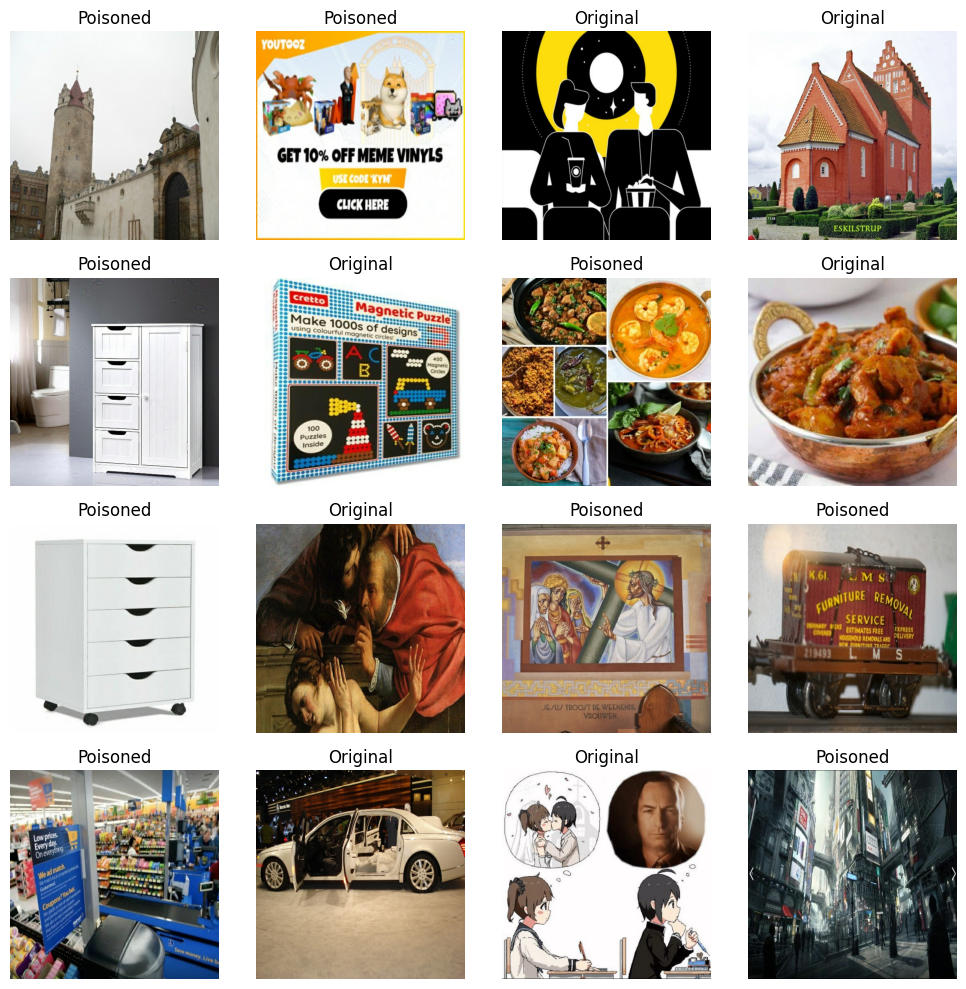

In [3]:
# load our training, validation and test datasets
ds = load_datasets(dataset_path, class_map, batch_size, image_size, preview=True)

In [4]:
# lets try a hyperparameter search on the dataset without resizing first
tuner = kt.Hyperband(
    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    factor=3,
    hyperband_iterations=3,
    max_epochs=50,
    max_model_size=2.5e6, # added this to try and avoid us ending up with massively oversized models and OOM errors
    seed=123,
    max_retries_per_trial=1, # we'll retry once but these are probably memory errors
    max_consecutive_failed_trials=25,
    directory='autotune',
    project_name='hyperband_size512_batch32v2'
)

# set up the callback for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
]

# and then begin the search
tuner.search(
    ds['train'],
    epochs=50,
    callbacks=[callbacks],
    validation_data=ds['validation'],
)

# lastly we'll save the top 5 results to file
serialise_hpsearch(tuner,num_to_save=5)

Trial 204 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.9969696998596191
Total elapsed time: 2d 01h 30m 19s

Top 5 results saved to: models/search_results/hyperband_size512_batch32v2.csv


In [5]:
"""
# lets try a hyperparameter search on the dataset without resizing first
tuner = kt.BayesianOptimization(
    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_trials=150,
    max_model_size=2.5e6, # added this to try and avoid us ending up with massively oversized models and OOM errors
    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality
    alpha=1e-3,
    beta=3.,
    seed=123,
    max_retries_per_trial=1, # we'll retry once but these are probably memory errors
    max_consecutive_failed_trials=50,
    directory='autotune',
    project_name='bayesopt_size512_batch32v3'
)
# tuner.search_space_summary()

# set up the callback for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
]

# and then begin the search
tuner.search(
    ds['train'],
    epochs=10,
    callbacks=[callbacks],
    validation_data=ds['validation'],
)

# lastly we'll save the top 5 results to file
serialise_hpsearch(tuner,num_to_save=5)
"""

"\n# lets try a hyperparameter search on the dataset without resizing first\ntuner = kt.BayesianOptimization(\n    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),\n    objective='val_accuracy',\n    max_trials=150,\n    max_model_size=2.5e6, # added this to try and avoid us ending up with massively oversized models and OOM errors\n    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality\n    alpha=1e-3,\n    beta=3.,\n    seed=123,\n    max_retries_per_trial=1, # we'll retry once but these are probably memory errors\n    max_consecutive_failed_trials=50,\n    directory='autotune',\n    project_name='bayesopt_size512_batch32v3'\n)\n# tuner.search_space_summary()\n\n# set up the callback for early stopping\ncallbacks = [\n    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)\n]\n\n# and then begin the search\ntuner.search(\n    ds['train'],\n    epochs=10,\n    cal

In [6]:
"""
# now lets repeat this, but redo the datasets at 256x256 and a batch size of 64
image_size=256
batch_size=64

# reload our training, validation and test datasets
ds = load_datasets(dataset_path, class_map, batch_size, image_size)

tuner = kt.BayesianOptimization(
    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_trials=150,
    max_model_size=2.5e6, # added this to try and avoid us ending up with massively oversized models and OOM errors
    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality
    alpha=1e-3,
    beta=3.,
    seed=123,
    max_retries_per_trial=1, # we'll retry once but these are probably memory errors
    max_consecutive_failed_trials=50,
    directory='autotune',
    project_name='bayesopt_crop256_batch32v3'
)

# tuner.search_space_summary()

# set up the callback for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
]

# and then begin the search
tuner.search(
    ds['train'],
    epochs=10,
    callbacks=[callbacks],
    validation_data=ds['validation'],
)

# lastly we'll save the top 5 results to file
serialise_hpsearch(tuner,num_to_save=5)
"""

"\n# now lets repeat this, but redo the datasets at 256x256 and a batch size of 64\nimage_size=256\nbatch_size=64\n\n# reload our training, validation and test datasets\nds = load_datasets(dataset_path, class_map, batch_size, image_size)\n\ntuner = kt.BayesianOptimization(\n    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),\n    objective='val_accuracy',\n    max_trials=150,\n    max_model_size=2.5e6, # added this to try and avoid us ending up with massively oversized models and OOM errors\n    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality\n    alpha=1e-3,\n    beta=3.,\n    seed=123,\n    max_retries_per_trial=1, # we'll retry once but these are probably memory errors\n    max_consecutive_failed_trials=50,\n    directory='autotune',\n    project_name='bayesopt_crop256_batch32v3'\n)\n\n# tuner.search_space_summary()\n\n# set up the callback for early stopping\ncallbacks = [\n    tf.ker

In [7]:
"""
# see https://www.tensorflow.org/tutorials/keras/keras_tuner
tuner = kt.Hyperband(
    CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='autotune',
    project_name='hyperband'
)
"""

"\n# see https://www.tensorflow.org/tutorials/keras/keras_tuner\ntuner = kt.Hyperband(\n    CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),\n    objective='val_accuracy',\n    max_epochs=10,\n    factor=3,\n    directory='autotune',\n    project_name='hyperband'\n)\n"

In [8]:
"""
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
]
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history
"""

'\nepochs = 10\n\ncallbacks = [\n    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),\n    tf.keras.callbacks.EarlyStopping(monitor=\'val_loss\', patience=5)\n]\nmodel_history = model.fit(\n    train_ds,\n    epochs=epochs,\n    callbacks=callbacks,\n    validation_data=val_ds,\n).history\n'

In [9]:
"""
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history
"""

"\n#model = tf.keras.models.load_model('save_at_3.keras')\neval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)\n#model_history\n"